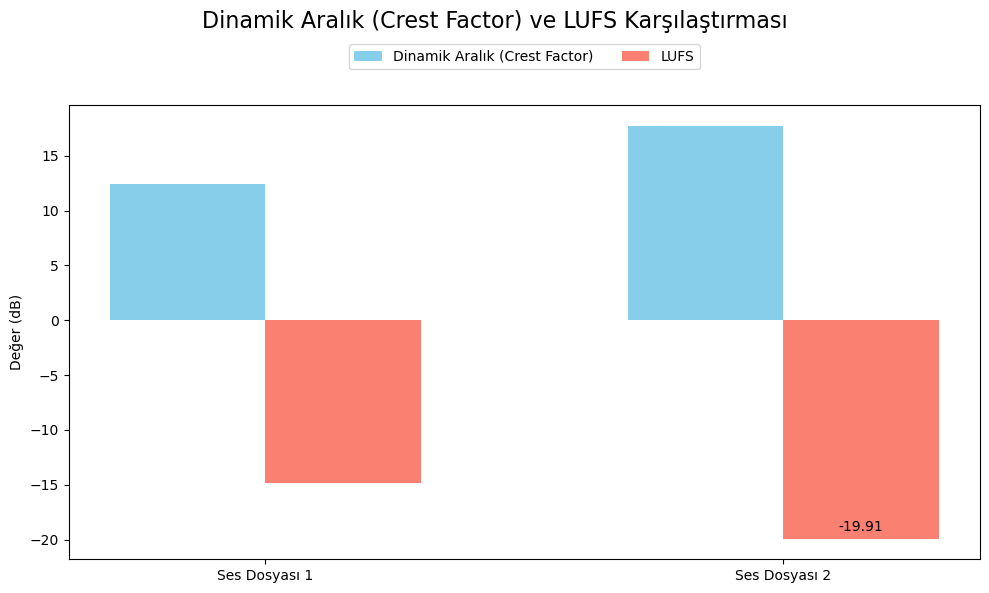

In [65]:
# Gerekli kütüphanelerin içe aktarılması
import matplotlib.pyplot as plt
import numpy as np
import librosa
import pyloudnorm as pyln

# İşlenecek ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav"
file_2 = "/Users/nazimerensahin/Desktop/2.wav"

# İşlenecek ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1"
label_2 = "Ses Dosyası 2"

# Ses dosyalarını yükle
wave_1, sr_1 = librosa.load(file_1, sr=None)
wave_2, sr_2 = librosa.load(file_2, sr=None)

# LUFS ölçümü için bir 'Meter' nesnesi oluştur
meter = pyln.Meter(sr_1)

# 1. ses dosyasının tepe ve RMS değerlerini hesapla
max_1 = np.max(np.abs(wave_1))
rms_1 = np.sqrt(np.mean(wave_1 ** 2))

# 2. ses dosyasının tepe ve RMS değerlerini hesapla
max_2 = np.max(np.abs(wave_2))
rms_2 = np.sqrt(np.mean(wave_2 ** 2))

# Crest Factor hesapla (20 * log10(peek / rms))
cf_1 = 20 * np.log10(max_1 / rms_1) if rms_1 > 0 else -np.inf
tcf_2 = 20 * np.log10(max_2 / rms_2) if rms_2 > 0 else -np.inf

# LUFS (algılanan ses yüksekliği) hesapla
lufs_1 = meter.integrated_loudness(wave_1)
lufs_2 = meter.integrated_loudness(wave_2)

# Grafik çizimi için ayarları
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.3

# Dinamik aralık (crest factor) bar grafiği
bar1 = ax.bar(x - width/2, [cf_1, tcf_2], 
width, label="Dinamik Aralık (Crest Factor)", color='skyblue')

# LUFS bar grafiği
bar2 = ax.bar(x + width/2, [lufs_1, lufs_2], 
width, label="LUFS", color='salmon')

# Her barın üstüne değer etiketlerini yazdır
for bars in [bar1, bar2]:
	for bar in bars:
		height = bar.get_height()
ax.annotate(f'{height:.2f}', 
xy=(bar.get_x() + bar.get_width() / 2, height),
xytext=(0, 3), textcoords="offset points",
ha='center', va='bottom')

# Görsel ayarlamalar
ax.set_ylabel("Değer (dB)")
ax.set_xticks(x)
ax.set_xticklabels([label_1, label_2])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("Dinamik Aralık (Crest Factor) ve LUFS Karşılaştırması", 
fontsize=16)
plt.show()